In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

print("All libraries loaded!")

All libraries loaded!


In [2]:
import random

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 hours of energy data
hours = list(range(1, 101))
normal_consumption = np.random.normal(loc=200, scale=20, size=100)

# Inject anomalies (spikes) at specific hours
normal_consumption[20] = 450  # Spike at hour 20
normal_consumption[45] = 500  # Spike at hour 45
normal_consumption[70] = 480  # Spike at hour 70
normal_consumption[90] = 420  # Spike at hour 90

# Create DataFrame
df = pd.DataFrame({
    'Hour': hours,
    'Energy_Consumption_kWh': normal_consumption.round(2)
})

print(df.head(10))
print(f"\nTotal rows: {len(df)}")

   Hour  Energy_Consumption_kWh
0     1                  209.93
1     2                  197.23
2     3                  212.95
3     4                  230.46
4     5                  195.32
5     6                  195.32
6     7                  231.58
7     8                  215.35
8     9                  190.61
9    10                  210.85

Total rows: 100


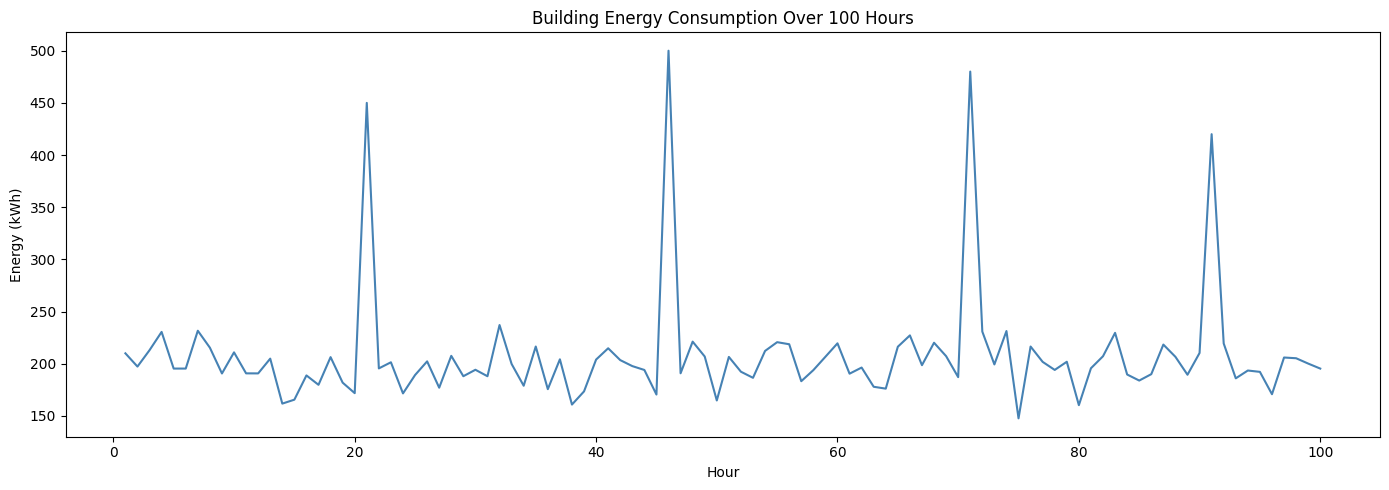

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Hour'], df['Energy_Consumption_kWh'], color='steelblue', linewidth=1.5)
plt.title('Building Energy Consumption Over 100 Hours')
plt.xlabel('Hour')
plt.ylabel('Energy (kWh)')
plt.tight_layout()
plt.show()

In [4]:
# Train Isolation Forest model
model = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = model.fit_predict(df[['Energy_Consumption_kWh']])

# -1 means anomaly, 1 means normal
df['Status'] = df['Anomaly'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

print(df[df['Status'] == 'Anomaly'])

    Hour  Energy_Consumption_kWh  Anomaly   Status
20    21                  450.00       -1  Anomaly
45    46                  500.00       -1  Anomaly
70    71                  480.00       -1  Anomaly
74    75                  147.61       -1  Anomaly
90    91                  420.00       -1  Anomaly


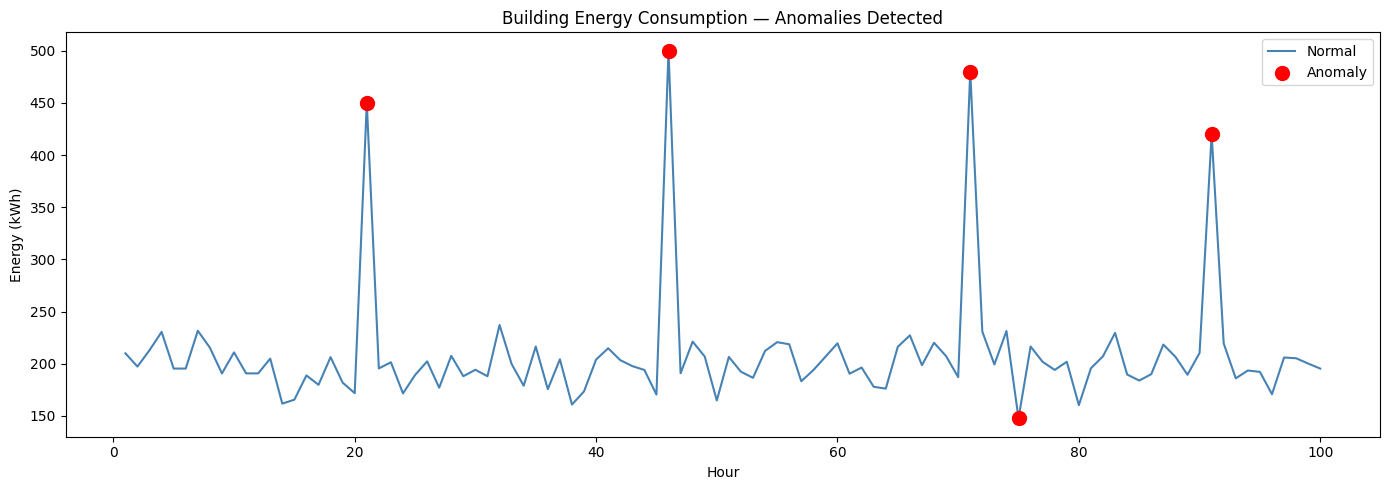

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['Hour'], df['Energy_Consumption_kWh'], color='steelblue', linewidth=1.5, label='Normal')
plt.scatter(df[df['Status'] == 'Anomaly']['Hour'], 
            df[df['Status'] == 'Anomaly']['Energy_Consumption_kWh'], 
            color='red', s=100, zorder=5, label='Anomaly')
plt.title('Building Energy Consumption — Anomalies Detected')
plt.xlabel('Hour')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def send_alert_email(anomaly_hours, anomaly_values):
    
    sender_email = "your_gmail@gmail.com"        # Your Gmail
    receiver_email = "your_email_here"      # Same email (testing)
    app_password = "your_app_password_here"         # Your 16 digit app password
    
    # Build email content
    subject = "⚠️ Energy Anomaly Detected — Immediate Attention Required"
    
    body = f"""
    Dear Facilities Manager,

    Our automated energy monitoring system has detected unusual energy consumption in the building.

    🚨 Anomalies Detected:
    """
    
    for hour, value in zip(anomaly_hours, anomaly_values):
        body += f"\n    • Hour {hour}: {value} kWh (abnormal reading)"
    
    body += """

    Please investigate these anomalies immediately to prevent potential equipment damage or energy waste.

    This is an automated alert from the Building Energy Monitor System.
    """
    
    # Send email
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))
    
    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
    
    print("✅ Alert email sent successfully!")

# Get anomaly data
anomalies = df[df['Status'] == 'Anomaly']
send_alert_email(anomalies['Hour'].tolist(), anomalies['Energy_Consumption_kWh'].tolist())

TimeoutError: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond

In [7]:
def send_alert_email(anomaly_hours, anomaly_values):
    
    sender_email = "your_gmail@gmail.com"
    receiver_email = "your_email_here"
    app_password = "your_app_password_here"
    
    subject = "⚠️ Energy Anomaly Detected — Immediate Attention Required"
    
    body = f"""
    Dear Facilities Manager,

    Our automated energy monitoring system has detected unusual energy consumption in the building.

    🚨 Anomalies Detected:
    """
    
    for hour, value in zip(anomaly_hours, anomaly_values):
        body += f"\n    • Hour {hour}: {value} kWh (abnormal reading)"
    
    body += """

    Please investigate these anomalies immediately to prevent potential equipment damage or energy waste.

    This is an automated alert from the Building Energy Monitor System.
    """
    
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))
    
    # Using port 587 instead of 465
    with smtplib.SMTP('smtp.gmail.com', 587) as server:
        server.ehlo()
        server.starttls()
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
    
    print("✅ Alert email sent successfully!")

anomalies = df[df['Status'] == 'Anomaly']
send_alert_email(anomalies['Hour'].tolist(), anomalies['Energy_Consumption_kWh'].tolist())

TimeoutError: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond

In [8]:
def send_alert_email(anomaly_hours, anomaly_values):
    
    sender_email = "your_gmail@gmail.com"
    receiver_email = "your_email_here"
    app_password = "your_app_password_here"
    
    subject = "⚠️ Energy Anomaly Detected — Immediate Attention Required"
    
    body = f"""
    Dear Facilities Manager,

    Our automated energy monitoring system has detected unusual energy consumption in the building.

    🚨 Anomalies Detected:
    """
    
    for hour, value in zip(anomaly_hours, anomaly_values):
        body += f"\n    • Hour {hour}: {value} kWh (abnormal reading)"
    
    body += """

    Please investigate these anomalies immediately to prevent potential equipment damage or energy waste.

    This is an automated alert from the Building Energy Monitor System.
    """
    
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))
    
    # Using port 587 instead of 465
    with smtplib.SMTP('smtp.gmail.com', 587) as server:
        server.ehlo()
        server.starttls()
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
    
    print("✅ Alert email sent successfully!")

anomalies = df[df['Status'] == 'Anomaly']
send_alert_email(anomalies['Hour'].tolist(), anomalies['Energy_Consumption_kWh'].tolist())

SMTPAuthenticationError: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials d2e1a72fcca58-82f8ec0566dsm8754077b3a.57 - gsmtp')

In [9]:
anomalies = df[df['Status'] == 'Anomaly']
send_alert_email(anomalies['Hour'].tolist(), anomalies['Energy_Consumption_kWh'].tolist())

SMTPAuthenticationError: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials d2e1a72fcca58-82f8ebe6439sm8698564b3a.41 - gsmtp')

In [10]:
sender_email = "your_email_here"
app_password = "your_app_password_here"  # 16 characters no spaces

In [11]:
def send_alert_email(anomaly_hours, anomaly_values):
    
    sender_email = "your_email_here"        # Your actual Gmail
    receiver_email = "your_email_here"      # Same email
    app_password = "your_app_password_here"            # 16 chars no spaces
    
    subject = "⚠️ Energy Anomaly Detected — Immediate Attention Required"
    
    body = f"""
    Dear Facilities Manager,

    Our automated energy monitoring system has detected unusual energy consumption in the building.

    🚨 Anomalies Detected:
    """
    
    for hour, value in zip(anomaly_hours, anomaly_values):
        body += f"\n    • Hour {hour}: {value} kWh (abnormal reading)"
    
    body += """

    Please investigate these anomalies immediately to prevent potential equipment damage or energy waste.

    This is an automated alert from the Building Energy Monitor System.
    """
    
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))
    
    with smtplib.SMTP('smtp.gmail.com', 587) as server:
        server.ehlo()
        server.starttls()
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
    
    print("✅ Alert email sent successfully!")

anomalies = df[df['Status'] == 'Anomaly']
send_alert_email(anomalies['Hour'].tolist(), anomalies['Energy_Consumption_kWh'].tolist())

✅ Alert email sent successfully!


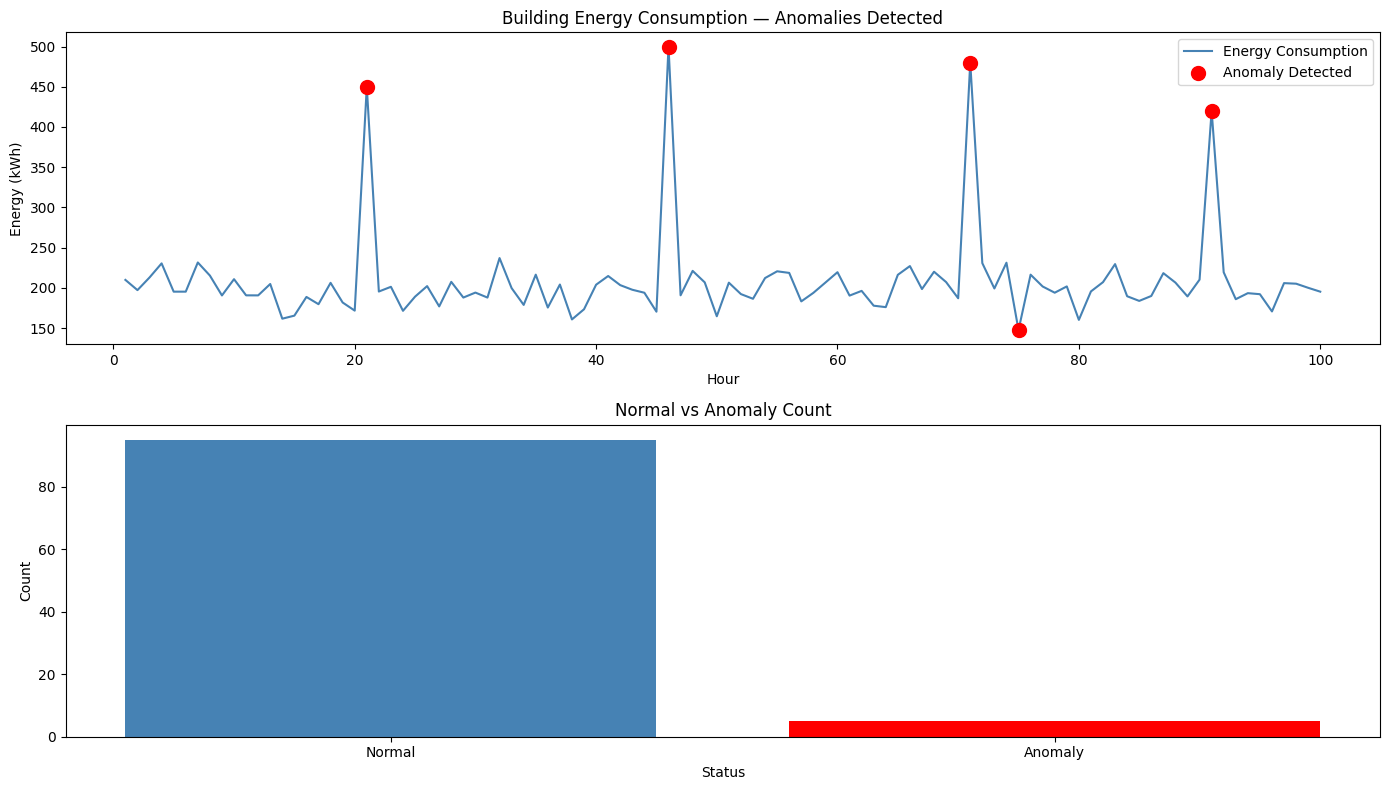

In [12]:
# Final summary chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1 - Energy consumption with anomalies
ax1.plot(df['Hour'], df['Energy_Consumption_kWh'], color='steelblue', linewidth=1.5, label='Energy Consumption')
ax1.scatter(df[df['Status'] == 'Anomaly']['Hour'], 
            df[df['Status'] == 'Anomaly']['Energy_Consumption_kWh'], 
            color='red', s=100, zorder=5, label='Anomaly Detected')
ax1.set_title('Building Energy Consumption — Anomalies Detected')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Energy (kWh)')
ax1.legend()

# Chart 2 - Normal vs Anomaly count
status_counts = df['Status'].value_counts()
ax2.bar(status_counts.index, status_counts.values, color=['steelblue', 'red'])
ax2.set_title('Normal vs Anomaly Count')
ax2.set_xlabel('Status')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
import os

def send_alert_email(anomaly_hours, anomaly_values):
    
    sender_email = os.environ.get('EMAIL')
    receiver_email = os.environ.get('EMAIL')
    app_password = os.environ.get('EMAIL_PASSWORD')